<a href="https://colab.research.google.com/github/KaizokuOu56/movingMirror/blob/main/trials1/sin_trial2d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/KaizokuOu56/movingMirror.git

Cloning into 'movingMirror'...
remote: Enumerating objects: 163, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 163 (delta 30), reused 42 (delta 12), pack-reused 93 (from 1)
Receiving objects: 100% (163/163), 174.69 MiB | 28.39 MiB/s, done.
Resolving deltas: 100% (58/58), done.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np

N = 100          # grid size
K = 10           # Fourier modes
num_samples = 15000
epochs = 10

In [4]:
t = np.linspace(0, 1, N, endpoint=False)

In [5]:
rng = np.random.default_rng(42)

Wr = rng.normal(size=(N, N, N))
Wi = rng.normal(size=(N, N, N))
alpha = 0.1
W = Wr + 1j * Wi
W = alpha * W

br = rng.normal(size=(N, N))
bi = rng.normal(size=(N, N))
b = br + 1j * bi
b = alpha * b

In [6]:
def sample_fourier_series(t, K):
    """
    Returns x ∈ ℂ^N
    """
    x = np.zeros_like(t, dtype=np.complex128)

    for k in range(-K, K + 1):
        a_k = np.random.uniform(-1,1)
        x += a_k * np.sin(2 * np.pi * k * t)

    return x

In [7]:
X = np.zeros((num_samples, N), dtype=np.complex128)
Y = np.zeros((num_samples, N, N), dtype=np.complex128)

for i in range(num_samples):
    x = sample_fourier_series(t, K)
    y = np.sin(W @ x + b)
    y = y / np.linalg.norm(y, axis=1, keepdims = True)

    # x /= np.linalg.norm(x)
    # y /= np.linalg.norm(y)

    X[i] = x
    Y[i] = y

    if(i % 1000 == 0):
        print(f"{i} / {num_samples} samples")
print("Done son")

0 / 15000 samples
1000 / 15000 samples
2000 / 15000 samples
3000 / 15000 samples
4000 / 15000 samples
5000 / 15000 samples
6000 / 15000 samples
7000 / 15000 samples
8000 / 15000 samples
9000 / 15000 samples
10000 / 15000 samples
11000 / 15000 samples
12000 / 15000 samples
13000 / 15000 samples
14000 / 15000 samples
Done son


In [ ]:
# import os

# # Define the filename for the dataset
# dataset_filename = '2d_y_sin_trial_dataset.npz'

# # Define the path to save the dataset in Google Drive
# gdrive_path = '/content/drive/MyDrive/movingMirror/models/2d_sin/data'
# save_path = os.path.join(gdrive_path, dataset_filename)

# # Ensure the Google Drive directory exists (optional, but good practice)
# os.makedirs(gdrive_path, exist_ok=True)

# # Save X and Y into a compressed .npz file in Google Drive
# np.savez_compressed(save_path, X=X, Y=Y)

# print(f"Dataset saved successfully to {save_path}")

In [ ]:
# import numpy as np

# # Define the filename (same as used for saving)
# dataset_filename = 'fourier_series_dataset.npz'

# # Load the dataset
# data = np.load(dataset_filename)

# # Access the arrays
# X_loaded = data['X']
# Y_loaded = data['Y']

# print(f"Loaded X shape: {X_loaded.shape}")
# print(f"Loaded Y shape: {Y_loaded.shape}")

# # You can now use X_loaded and Y_loaded for your model or further analysis

In [9]:
import os
save_dir = "/content/drive/MyDrive/movingMirror/experimental_data/trial6"
os.makedirs(save_dir, exist_ok=True)

# Generate random sample

In [10]:
import matplotlib.pyplot as plt

# Select a random sample index
random_sample_idx = np.random.randint(0, num_samples)

x_sample = X[random_sample_idx]
y_sample = Y[random_sample_idx]

print(f"Visualizing sample index: {random_sample_idx}")

Visualizing sample index: 14330


### Plotting x (Fourier Series Sample)

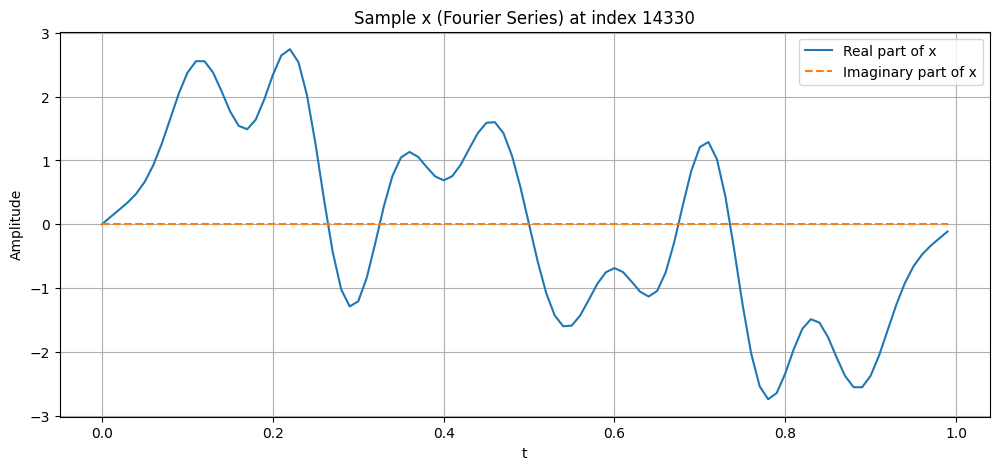

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(t, x_sample.real, label='Real part of x')
plt.plot(t, x_sample.imag, label='Imaginary part of x', linestyle='--')
plt.title(f'Sample x (Fourier Series) at index {random_sample_idx}')
plt.xlabel('t')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

# save_path = os.path.join(save_dir, "sample_alpha_no_sin_visualization_x.png")
# fig.savefig(save_path, dpi=300, bbox_inches="tight")

### Visualizing y (Output from Model) as a Heatmap

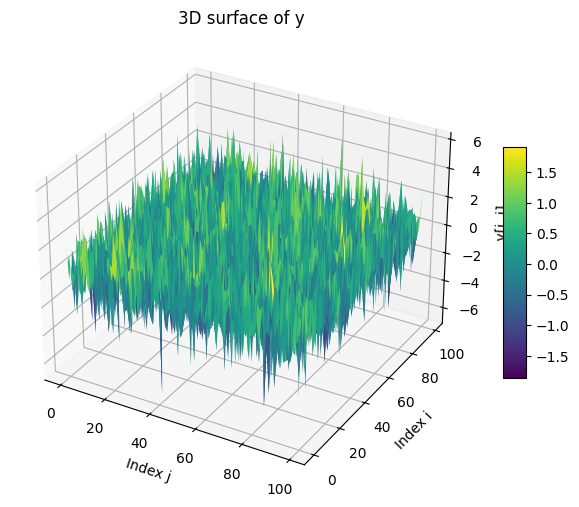

In [12]:
from mpl_toolkits.mplot3d import Axes3D  # noqa

test = np.zeros((200, 200), dtype=np.complex128)
test = W @ x_sample + b
testr = test.imag
# y shape: (200, 200)
ny, nx = testr.shape

_X, _Y = np.meshgrid(np.arange(nx), np.arange(ny))

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    _X, _Y, testr,
    cmap='viridis',
    linewidth=0,
    antialiased=True
)

ax.set_xlabel("Index j")
ax.set_ylabel("Index i")
ax.set_zlabel("y[i, j]")
ax.set_title("3D surface of y")

fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()

save_path = os.path.join(save_dir, "sample_rowWiseNorm_no_sin_visualisation_y.png")
fig.savefig(save_path, dpi=300, bbox_inches="tight")

In [ ]:
# testr = test.real
# ny, nx = testr.shape

# _X, _Y = np.meshgrid(np.arange(nx), np.arange(ny))

# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(111, projection='3d')

# surf = ax.plot_surface(
#     _X, _Y, testr,
#     cmap='viridis',
#     linewidth=0,
#     antialiased=True
# )

# ax.set_xlabel("Index j")
# ax.set_ylabel("Index i")
# ax.set_zlabel("y[i, j]")
# ax.set_title("3D surface of y")

# fig.colorbar(surf, shrink=0.5, aspect=10)
# plt.show()

# save_path = os.path.join(save_dir, "sample_norm_sin_visualisation_y_wNorm.png")
# fig.savefig(save_path, dpi=300, bbox_inches="tight")

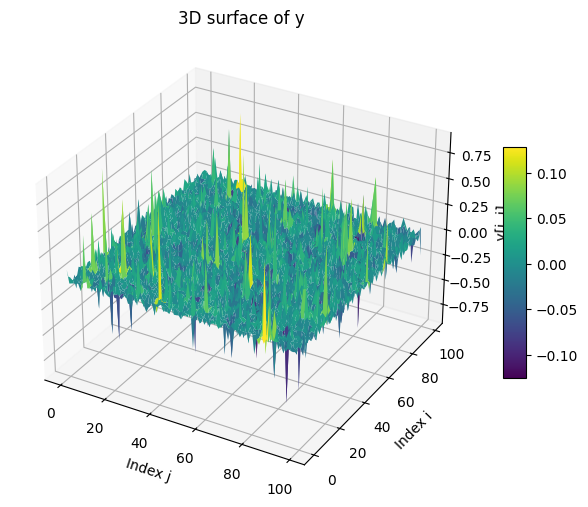

In [13]:
testr = y_sample.real
nx, ny = testr.shape
_X, _Y = np.meshgrid(np.arange(nx), np.arange(ny))

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    _X, _Y, testr,
    cmap='viridis',
    linewidth=0,
    antialiased=True
)

ax.set_xlabel("Index j")
ax.set_ylabel("Index i")
ax.set_zlabel("y[i, j]")
ax.set_title("3D surface of y")

fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()

save_path = os.path.join(save_dir, "sample_rowWiseNorm_sin_visualisation_y.png")
fig.savefig(save_path, dpi=300, bbox_inches="tight")

In [14]:
import torch
from torch.utils.data import Dataset

class Lifted2DOperatorDataset(Dataset):
    def __init__(self, X, Y):
        self.x = torch.tensor(X.real, dtype=torch.float32)        # (N, 200)
        self.y_r = torch.tensor(Y.real, dtype=torch.float32)      # (N, 200, 200)
        self.y_i = torch.tensor(Y.imag, dtype=torch.float32)      # (N, 200, 200)

        self.H = self.y_r.shape[1]
        self.W = self.y_r.shape[2]

        # precompute coordinate grid
        yy, xx = torch.meshgrid(
            torch.linspace(0, 1, self.H),
            torch.linspace(0, 1, self.W),
            indexing="ij"
        )
        self.coords = torch.stack([xx, yy])  # (2, H, W)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        # --- lift 1D x → 2D ---
        x1d = self.x[idx]                      # (200,)
        x2d = x1d[None, None, :].repeat(1, self.H, 1)
        # (1, H, W)

        # --- add coordinates ---
        inp = torch.cat([x2d, self.coords], dim=0)
        # (3, H, W)

        y_r = self.y_r[idx][None, :, :]        # (1, H, W)
        y_i = self.y_i[idx][None, :, :]        # (1, H, W)

        return inp, y_r, y_i

In [15]:
!pip install neuraloperator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 131.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 7.0 MB/s eta 0:00:00


In [16]:
from neuralop.models import FNO

def make_fno2d():
    return FNO(
        n_modes=(16, 16),
        hidden_channels=64,
        in_channels=3,    # x + (x,y) coords
        out_channels=1,
        n_layers=4
    )

model_real = make_fno2d()
model_imag = make_fno2d()

In [17]:
from torch.utils.data import DataLoader
import torch.nn.functional as F
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_real.to(device)
model_imag.to(device)

dataset = Lifted2DOperatorDataset(X, Y)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

opt_real = torch.optim.Adam(model_real.parameters(), lr=1e-3)
opt_imag = torch.optim.Adam(model_imag.parameters(), lr=1e-3)

In [18]:
losses = []

model_real.train()
model_imag.train()

for epoch in range(epochs):
    epoch_loss = 0.0
    pbar = tqdm(loader, desc=f"Epoch {epoch}", leave=False)

    for x, y_r, y_i in pbar:
        x   = x.to(device)
        y_r = y_r.to(device)
        y_i = y_i.to(device)

        # --- real ---
        pred_r = model_real(x)
        loss_r = F.mse_loss(pred_r, y_r)
        opt_real.zero_grad()
        loss_r.backward()
        opt_real.step()

        # --- imag ---
        pred_i = model_imag(x)
        loss_i = F.mse_loss(pred_i, y_i)
        opt_imag.zero_grad()
        loss_i.backward()
        opt_imag.step()

        loss = loss_r + loss_i
        epoch_loss += loss.item()

        pbar.set_postfix({
            "Re": f"{loss_r.item():.2e}",
            "Im": f"{loss_i.item():.2e}"
        })

    epoch_loss /= len(loader)
    losses.append(epoch_loss)

    print(f"Epoch {epoch} | Total loss = {epoch_loss:.3e}")


Epoch 0:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 0 | Total loss = 9.990e-03


Epoch 1:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 1 | Total loss = 9.822e-03


Epoch 2:   0%|          | 0/3750 [00:00<?, ?it/s]

...

Epoch 7 | Total loss = 6.482e-03


Epoch 8:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 8 | Total loss = 6.227e-03


Epoch 9:   0%|          | 0/3750 [00:00<?, ?it/s]

Epoch 9 | Total loss = 6.011e-03


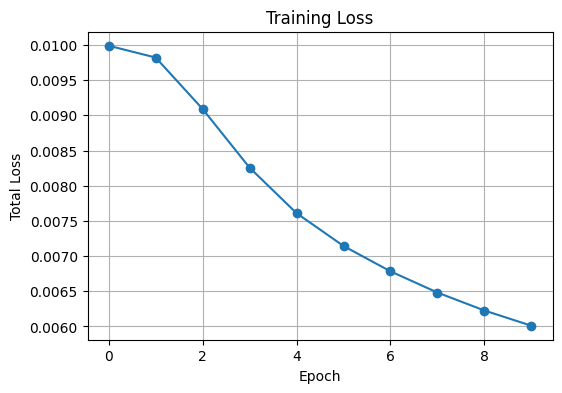

In [19]:
epochs_plotting = np.arange(len(losses))
plt.figure(figsize=(6,4))
plt.plot(epochs_plotting, losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Training Loss")
plt.grid(True)
save_path = os.path.join(save_dir, "training_loss.png")
fig.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

In [20]:
model_real.eval()
model_imag.eval()

# Get a sample from the dataset (using the previously defined random_sample_idx)
x_sample_tensor, y_r_sample_tensor, y_i_sample_tensor = dataset[random_sample_idx]

# Add batch dimension and move to device
x_sample_tensor = x_sample_tensor.unsqueeze(0).to(device)
y_r_sample_tensor = y_r_sample_tensor.unsqueeze(0).to(device)
y_i_sample_tensor = y_i_sample_tensor.unsqueeze(0).to(device)

# Make predictions
with torch.no_grad():
    pred_r_sample = model_real(x_sample_tensor)
    pred_i_sample = model_imag(x_sample_tensor)

# Calculate element-wise squared error
loss_r_matrix = (pred_r_sample - y_r_sample_tensor).pow(2).squeeze(0).cpu().numpy() # Remove batch dim, move to cpu, convert to numpy
loss_i_matrix = (pred_i_sample - y_i_sample_tensor).pow(2).squeeze(0).cpu().numpy() # Remove batch dim, move to cpu, convert to numpy

# Define the filename for saving
loss_filename = os.path.join(save_dir, f'prediction_loss_sample_{random_sample_idx}.npz')

# Save the loss matrices
np.savez_compressed(loss_filename, real_loss=loss_r_matrix, imag_loss=loss_i_matrix)

print(f"Element-wise prediction loss matrices for sample {random_sample_idx} saved to {loss_filename}")
print(f"Shape of real_loss_matrix: {loss_r_matrix.shape}")
print(f"Shape of imag_loss_matrix: {loss_i_matrix.shape}")

Element-wise prediction loss matrices for sample 14330 saved to /content/drive/MyDrive/movingMirror/experimental_data/trial6/prediction_loss_sample_14330.npz
Shape of real_loss_matrix: (1, 100, 100)
Shape of imag_loss_matrix: (1, 100, 100)


To load and inspect the saved loss matrices, you can use the following code:

Loaded real loss matrix shape: (1, 100, 100)
Loaded imaginary loss matrix shape: (1, 100, 100)


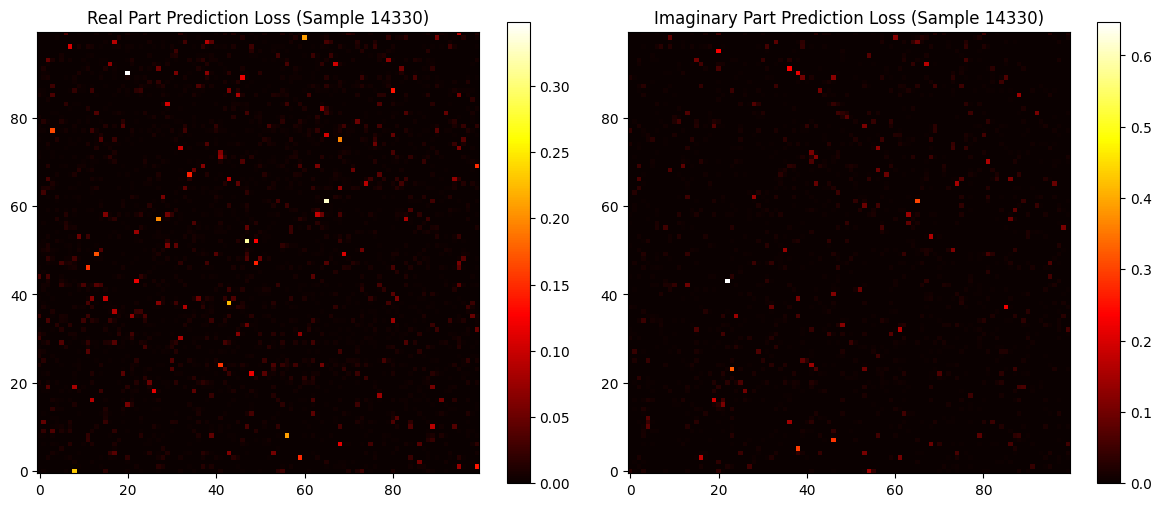

In [21]:
# Load the saved loss data
loaded_loss_data = np.load(loss_filename)

loaded_real_loss = loaded_loss_data['real_loss']
loaded_imag_loss = loaded_loss_data['imag_loss']

print(f"Loaded real loss matrix shape: {loaded_real_loss.shape}")
print(f"Loaded imaginary loss matrix shape: {loaded_imag_loss.shape}")

# You can visualize these matrices, for example, using imshow
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(loaded_real_loss.squeeze(), cmap='hot', origin='lower')
plt.title(f'Real Part Prediction Loss (Sample {random_sample_idx})')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(loaded_imag_loss.squeeze(), cmap='hot', origin='lower')
plt.title(f'Imaginary Part Prediction Loss (Sample {random_sample_idx})')
plt.colorbar()

plt.tight_layout()
plt.show()

save_path = os.path.join(save_dir, "random_sample_loss.png")
fig.savefig(save_path, dpi=300, bbox_inches="tight")

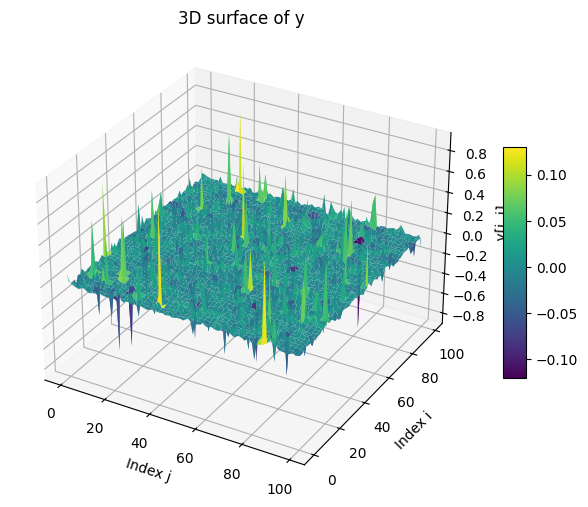

In [22]:
testr = pred_r_sample.squeeze().cpu().numpy()
nx, ny = testr.shape
_X, _Y = np.meshgrid(np.arange(nx), np.arange(ny))

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    _X, _Y, testr,
    cmap='viridis',
    linewidth=0,
    antialiased=True
)

ax.set_xlabel("Index j")
ax.set_ylabel("Index i")
ax.set_zlabel("y[i, j]")
ax.set_title("3D surface of y")

fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()

save_path = os.path.join(save_dir, "random_sample_pred_real.png")
fig.savefig(save_path, dpi=300, bbox_inches="tight")

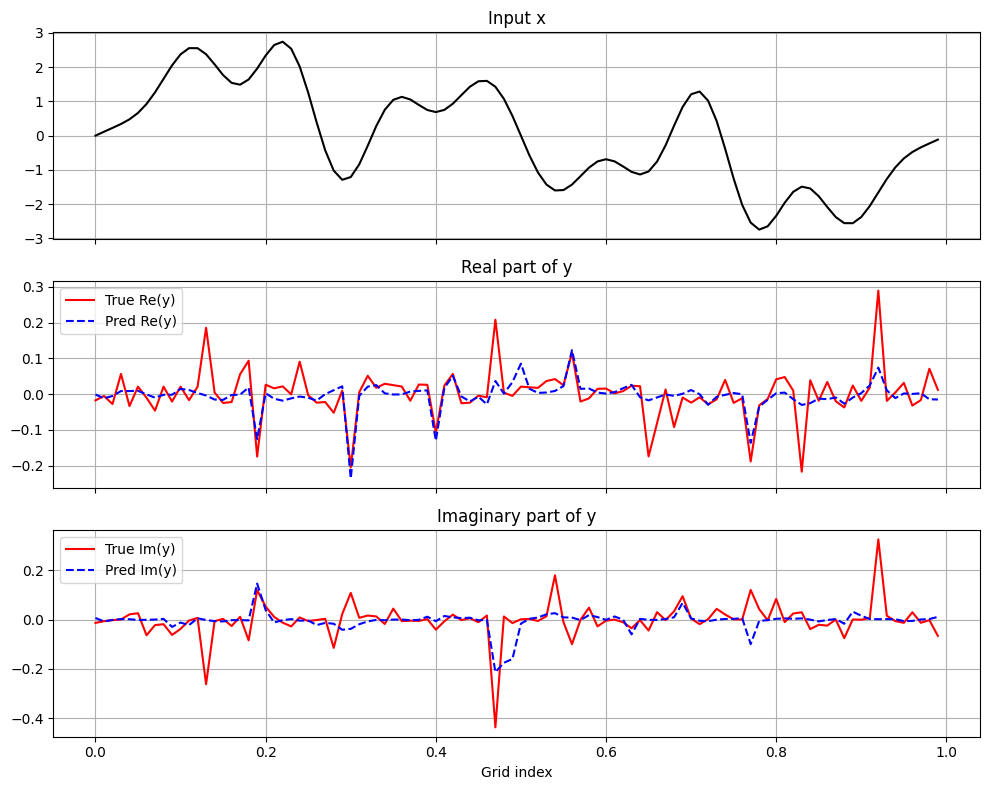

In [30]:
i = np.random.randint(0, 100)
d2_input = X[random_sample_idx]
d2_sample_r = Y[random_sample_idx][i, :].real
d2_sample_i = Y[random_sample_idx][i, :].imag
d2_pred_r = pred_r_sample.squeeze().cpu().numpy()[i, :]
d2_pred_i = pred_i_sample.squeeze().cpu().numpy()[i, :]



fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# --- x ---
axs[0].plot(t, d2_input, color="black")
axs[0].set_title("Input x")
axs[0].grid(True)

# --- y real ---
axs[1].plot(t, d2_sample_r, label="True Re(y)", color="red")
axs[1].plot(t, d2_pred_r, label="Pred Re(y)", color="blue", linestyle="--")
axs[1].set_title("Real part of y")
axs[1].legend()
axs[1].grid(True)

# --- y imag ---
axs[2].plot(t, d2_sample_i, label="True Im(y)", color="red")
axs[2].plot(t, d2_pred_i, label="Pred Im(y)", color="blue", linestyle="--")
axs[2].set_title("Imaginary part of y")
axs[2].legend()
axs[2].grid(True)

plt.xlabel("Grid index")
plt.tight_layout()
plt.show()

save_path = os.path.join(save_dir, "PREDICTION.png")
fig.savefig(save_path, dpi=300, bbox_inches="tight")

In [31]:
%cd movingMirror/trials1

/content/movingMirror/trials1
